<a href="https://colab.research.google.com/github/logankim0913/EE_467_Final_Project/blob/main/phase2_pair2_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data
Loading data from the Benign/Dictionary Brute Force/DNS_Spoofing dataset. Since the CIC IoT Intrusion dataset for benign traffic comes with a number of batches of data, which we are using to train our autoencoder, we can simply designate some of them for training and the other for testing instead of spliting up a single dataset. This is done under the assumption that these benign traffic datasets are independent from each other; training the autoencoder with one of them should not "leak" any information about the test benign traffic dataset.

In [98]:
import pandas as pd

# scaling only on benign data
bfd = pd.read_csv("DictionaryBruteForce.pcap.csv")
spoof = pd.read_csv("DNS_Spoofing.pcap.csv")
benign = pd.read_csv("BenignTraffic.pcap.csv")
benign1 = pd.read_csv("BenignTraffic1.pcap.csv")
benign2 = pd.read_csv("BenignTraffic2.pcap.csv")
benign3 = pd.read_csv("BenignTraffic3.pcap.csv")

# use different datasets for train/val/test benign
train_benign = pd.concat([benign, benign1])
val_benign = benign2
test_benign = benign3

# Establish the seed for any random_state functions later open
RANDOM_SEED = 42

## Preprocessing - Drop problematic features
Because we see that features like `Rate` has unprocessable values, we will remove that feature for preprocessing step later.

In [99]:
import numpy as np

def clean_df(df):
    #Replaces inf/-inf with NaN and drops those selected rows
    return df.replace([np.inf, -np.inf], np.nan).dropna()

# handle infinite values before scaling drop rows with infinity
bfd = clean_df(bfd)
spoof = clean_df(spoof)
benign_train = clean_df(train_benign)
benign_val = clean_df(val_benign)
benign_test = clean_df(test_benign)

## Preprocessing
### Standard Scaling

One of the feature scaling methods we are exploring is `StandardScaler()`. If the features have not much effects from outliers, it will scale the values normally.

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#define columns so consistent everywhere
feature_cols = benign_train.columns.tolist()
#training set for benign
X_train = scaler.fit_transform(benign_train[feature_cols].values) # Assuming benign_train has all the relevant columns
#validation set for benign
X_val_benign = scaler.transform(benign_val[feature_cols].values)

# test set includes benign_test + all attacks
test = pd.concat(
    [
        benign_test.assign(label=0),   # 0 = benign
        bfd.assign(label=1),           # 1 = attack
        spoof.assign(label=1),
    ],
    ignore_index=True
)

#test set has both benign and attack
X_test = scaler.transform(test[feature_cols].values)
#labels for test set
y_test = test["label"].values

print("Shapes:")
print("X_train (benign):", X_train.shape)
print("X_val_benign:", X_val_benign.shape)
print("X_test (mixed):", X_test.shape, "y_test:", y_test.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 39)
X_val_benign: (310395, 39)
X_test (mixed): (321781, 39) y_test: (321781,)

Test class balance:
1    191957
0    129824
Name: count, dtype: int64


### Robust Scaling

We also implement the `Robust Scaling` to remove potential outliers present in our original benign traffic dataset.

In [101]:
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
# training set for benign
X_train_robust = rscaler.fit_transform(benign_train[feature_cols].values) # Assuming benign_train has all the relevant columns
# validation set for benign
X_val_benign_robust = rscaler.transform(benign_val[feature_cols].values)

# test set has both benign and attack
X_test_robust = rscaler.transform(test[feature_cols].values)
#labels for test set
y_test_robust = test["label"].values

# Shapes should be the same as post-StandardScaling
print("Shapes:")
print("X_train (benign):", X_train_robust.shape)
print("X_val_benign:", X_val_benign_robust.shape)
print("X_test (mixed):", X_test_robust.shape, "y_test:", y_test_robust.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 39)
X_val_benign: (310395, 39)
X_test (mixed): (321781, 39) y_test: (321781,)

Test class balance:
1    191957
0    129824
Name: count, dtype: int64


## Autoencoder Design

After data features are scaled properly, we define the structure of the autoencoder that will be used as a classifier to detect IoT attacks.

In [102]:
from tensorflow import keras
from tensorflow.keras import layers
#for reproducibility
import random
import tensorflow as tf

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

#Built autoencoder
def build_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    latent = layers.Dense(8, activation='relu')(x)

    # Decoder
    x = layers.Dense(16, activation='relu')(latent)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(input_dim)(x)

    model = keras.Model(inputs, outputs)

    encoder = keras.Model(inputs, latent)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model, encoder

#Adjust AE depth and bottleneck size for phase 2
#AE architecture tuning
def build_small_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(16, activation='relu')(inputs)
    latent = layers.Dense(4, activation='relu')(x)

    x = layers.Dense(16, activation='relu')(latent)
    outputs = layers.Dense(input_dim)(x)

    model = keras.Model(inputs, outputs)
    encoder = keras.Model(inputs, latent)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model, encoder

### Small Autoencoder

This section includes all instantiating, training, evaluating, and summarizing for small autoencoder

In [103]:
# Instantiate the small autoencoder
small_ae, small_encoder = build_small_autoencoder(X_train.shape[1])
print("Small Autoencoder Trainable Parameters:", count_parameters(small_ae))

# Train the small autoencoder
history_small_ae = small_ae.fit(
    X_train_noisy, X_train,          # noisy input, clean target
    validation_data=(X_val_benign, X_val_benign),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

# Calculate reconstruction error and threshold for small autoencoder
val_errors_small_ae = reconstruction_error(small_ae, X_val_benign)
threshold_small_ae = compute_threshold(val_errors_small_ae, 0.005)
print("Small Autoencoder 0.5% FPR Threshold:", threshold_small_ae)

# Make predictions on test set
small_ae_preds, small_ae_errors = ae_predict(small_ae, X_test, threshold_small_ae)

# Evaluate Small Autoencoder
tn_small_ae, fp_small_ae, fn_small_ae, tp_small_ae = confusion_matrix(y_test, small_ae_preds).ravel()
small_ae_recall = tp_small_ae / (tp_small_ae + fn_small_ae)
small_ae_fpr = fp_small_ae / (fp_small_ae + tn_small_ae)
small_ae_f1 = f1_score(y_test, small_ae_preds)
print("Small AE Recall @ 0.5% FPR:", small_ae_recall)
print("Small AE Actual FPR:", small_ae_fpr, "\n")
print("Small AE Classification Report: \n\n", classification_report(y_test, small_ae_preds))

# Measure latency for small autoencoder
small_ae_total_s, small_ae_ms_per_sample = measure_avg_latency(
    lambda x: small_ae.predict(x, verbose=0),
    X_test_small
)
print(f"Small Autoencoder Total Time: {small_ae_total_s:.4f}s, MS per sample: {small_ae_ms_per_sample:.4f}ms")


Small Autoencoder Trainable Parameters: 1451
Epoch 1/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4846 - val_loss: 0.2979
Epoch 2/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3114 - val_loss: 0.2329
Epoch 3/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2733 - val_loss: 0.2187
Epoch 4/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2629 - val_loss: 0.2123
Epoch 5/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2565 - val_loss: 0.2075
Small Autoencoder 0.5% FPR Threshold: 7.669100773838617
Small AE Recall @ 0.5% FPR: 0.022734258193241194
Small AE Actual FPR: 0.007271382795168844 

Small AE Classification Report: 

               precision    recall  f1-score   support

           0       0.41      0.99      0.58    129824
           1       0.82      0.02      0.04    191957

    accuracy                           0.41    321781
   macro avg       0.61      0.51      0.31    321781
weighted avg       0.65      0.41      0.26    321781

Smal

And just instantiate the defined autoencoder. We will have one for standard scaled features and one for robust scaled ones.

In [104]:
#instantiate model
ae, encoder = build_autoencoder(X_train.shape[1])
ae_robust, encoder_robust = build_autoencoder(X_train_robust.shape[1])


#parameter count
def count_parameters(model):
    return np.sum([np.prod(v.shape) for v in model.trainable_weights])

print("Trainable Parameters:", count_parameters(ae))

Trainable Parameters: 3919


## Training the autoencoders

Now that the structure of our autoencoder is defined, we should train it with *only the benign traffic dataset* to ensure that it is **ONLY** optimized to represent the benign traffic datasets and nothing else. The *Gaussian noise* is added to introduce some variability in the training samples so that the autoencoder becomes more robust.

In [105]:
# Train autoencoder
import numpy as np

def add_gaussian_noise(X, sigma=0.05):
    Xn = X + np.random.normal(0.0, sigma, size=X.shape)
    return Xn

sigma = 0.05  # try 0.02, 0.05, 0.1
X_train_noisy = add_gaussian_noise(X_train, sigma=sigma)
X_train_robust_noisy = add_gaussian_noise(X_train_robust, sigma=sigma)
#robust AE training jumpy
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = ae.fit(
    X_train_noisy, X_train,          # noisy input, clean target
    validation_data=(X_val_benign, X_val_benign),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

history_robust = ae_robust.fit(
    X_train_robust_noisy, X_train_robust,          # noisy input, clean target
    validation_data=(X_val_benign_robust, X_val_benign_robust),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

# history = ae.fit(
#     X_train,
#     X_train,
#     epochs=40,
#     batch_size=256,
#     validation_data=(X_val_benign, X_val_benign),
#     verbose=1
# )

Epoch 1/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2449 - val_loss: 0.0787
Epoch 2/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0757 - val_loss: 0.0555
Epoch 3/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0595 - val_loss: 0.0443
Epoch 4/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0503 - val_loss: 0.0381
Epoch 5/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0451 - val_loss: 0.0345
Epoch 6/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0414 - val_loss: 0.0318
Epoch 7/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0389 - val_loss: 0.0302
Epoch 8/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0368 - val_loss: 0.0284
Epoch 9/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0350 - val_loss: 0.0274
Epoch 10/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0339 - val_loss: 0.0263
Epoch 11/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0329 - val_loss: 0.0259
Epoch 12/40
1285/1285 ━━━━━━━━

In [106]:
# Reconstruction error
def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    error = np.mean((X - reconstructed) ** 2, axis=1)
    return error

In [107]:
# Threshold at 0.5% FPR
def compute_threshold(val_errors, target_fpr=0.005):
    return np.percentile(val_errors, 100 * (1 - target_fpr))

val_errors = reconstruction_error(ae, X_val_benign)
threshold = compute_threshold(val_errors, 0.005)

print("0.5% FPR Threshold:", threshold)

0.5% FPR Threshold: 0.293248908663891


In [108]:
# AE detection on test set
def ae_predict(model, X, threshold):
    errors = reconstruction_error(model, X)
    preds = (errors > threshold).astype(int)
    return preds, errors
#robust should use its own threshold
val_errors_robust = reconstruction_error(ae_robust, X_val_benign_robust)
threshold_robust = compute_threshold(val_errors_robust, 0.005)

ae_preds, ae_errors = ae_predict(ae, X_test, threshold)
ae_robust_preds, ae_robust_errors = ae_predict(ae_robust, X_test_robust, threshold_robust)

## Create baseline models for performance comparison

We are also creating other baseline classifiers to see how our autoencoder classifier's performance is compared to other types of classifiers. Here, we are creating `LogisticRegression()` model for classification. Unlike autoencoder which requires only the benign traffic for its training, you need labeled datasets for both benign and attacks since Logistic Regression is a supervised classifier.

In [109]:
def count_lr_params(model):
  # Coefficients (one per feature per class, but binary only needs one set)
  n_coefficients = model.coef_.size

  # Intercepts (one per class, binary only needs one)
  n_intercepts = model.intercept_.size

  total_params = n_coefficients + n_intercepts
  print(f"Total parameters: {total_params}")


In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

bfd_train, bfd_test = train_test_split(
    bfd, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
spoof_train, spoof_test = train_test_split(
    spoof, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)

train_full = pd.concat(
    [
        benign_train.assign(label=0),
        bfd_train.assign(label=1),
        spoof_train.assign(label=1),
    ],
    ignore_index=True
)

test_full = pd.concat(
    [
        benign_test.assign(label=0),
        bfd_test.assign(label=1),
        spoof_test.assign(label=1),
    ],
    ignore_index=True
)

test = pd.concat(
    [
        benign_test.assign(label=0),
        bfd_test.assign(label=1),
        spoof_test.assign(label=1),
    ],
    ignore_index=True
)


X_train_full = scaler.transform(train_full[feature_cols].values)
y_train_full = train_full["label"].values

X_test_full = scaler.transform(test_full[feature_cols].values)
y_test_full = test_full["label"].values

#Logistic Regression baseline
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train_full, y_train_full)
lr_preds = logreg.predict(X_test_full)
count_lr_params(logreg)

Total parameters: 40


In [111]:
#Autoencoder Evaluation (Standard Scaling)
from sklearn.metrics import classification_report
tn, fp, fn, tp = confusion_matrix(y_test, ae_preds).ravel()

ae_recall = tp / (tp + fn)
ae_fpr = fp / (fp + tn)

#Autoencoder Evaluation (Robust Scaling)
tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test_robust, ae_robust_preds).ravel()

ae_robust_recall = tp_r / (tp_r + fn_r)
ae_robust_fpr = fp_r / (fp_r + tn_r)

#Logistic Regression Evaluation
tn, fp, fn, tp = confusion_matrix(y_test_full, lr_preds).ravel()

lr_recall = tp / (tp + fn)
lr_fpr = fp / (fp + tn)

print("AE (Standard) Recall @ 0.5% FPR:", ae_recall)
print("AE (Standard) Actual FPR:", ae_fpr, "\n")

print("AE (Robust) Recall @ 0.5% FPR:", ae_robust_recall)
print("AE (Robust) Actual FPR:", ae_robust_fpr, "\n")

print("AE (Standard) Classification Report: \n\n", classification_report(y_test, ae_preds))
print("\nAE (Robust) Classification Report: \n\n", classification_report(y_test_robust, ae_robust_preds))
print("\nLogistic Regression Classification Report: \n\n", classification_report(y_test_full, lr_preds))

print("LogReg Recall:", lr_recall)
print("LogReg FPR:", lr_fpr, "\n")

AE (Standard) Recall @ 0.5% FPR: 0.06592101356032862
AE (Standard) Actual FPR: 0.0054458343603648015 

AE (Robust) Recall @ 0.5% FPR: 0.13932286918424439
AE (Robust) Actual FPR: 0.005091508503820557 

AE (Standard) Classification Report: 

               precision    recall  f1-score   support

           0       0.42      0.99      0.59    129824
           1       0.95      0.07      0.12    191957

    accuracy                           0.44    321781
   macro avg       0.68      0.53      0.36    321781
weighted avg       0.73      0.44      0.31    321781


AE (Robust) Classification Report: 

               precision    recall  f1-score   support

           0       0.44      0.99      0.61    129824
           1       0.98      0.14      0.24    191957

    accuracy                           0.48    321781
   macro avg       0.71      0.57      0.43    321781
weighted avg       0.76      0.48      0.39    321781


Logistic Regression Classification Report: 

               preci

In [112]:
def distance_scoring(encoder, kmeans, X):
  latent = encoder.predict(X, verbose=0)
  distances = kmeans.transform(latent)
  min_distances = distances.min(axis=1)
  return min_distances

def ae_kmeans_predict(encoder, kmeans, X, threshold):
    distances = distance_scoring(encoder, kmeans, X)
    preds = (distances > threshold).astype(int)
    return preds, distances

In [113]:
from sklearn.cluster import MiniBatchKMeans, KMeans
latent_train = encoder.predict(X_train, verbose=0)
#kmeans = KMeans(random_state=0, max_iter=500)
#choose n_clusters for kmeans
kmeans = MiniBatchKMeans(
    n_clusters=8,
    random_state=RANDOM_SEED,
    batch_size=4096
)
kmeans.fit(latent_train)

distances = distance_scoring(encoder, kmeans, X_val_benign)
scoring_threshold = np.percentile(distances, 99.5)

ae_km_preds, ae_km_distances = ae_kmeans_predict(encoder, kmeans, X_test, scoring_threshold)

In [114]:
tn, fp, fn, tp = confusion_matrix(y_test, ae_km_preds).ravel()

ae_k_recall = tp / (tp + fn)
ae_k_fpr = fp / (fp + tn)

print("AE K-means Recall @ 0.5% FPR:", ae_k_recall)
print("AE K-Means Actual FPR:", ae_k_fpr, "\n")

kmeans_params = kmeans.cluster_centers_.size
print("KMeans centroid values:", kmeans_params)

print("AE Classification Report: \n\n", classification_report(y_test, ae_km_preds))

AE K-means Recall @ 0.5% FPR: 0.024281479706392578
AE K-Means Actual FPR: 0.007363815627310821 

KMeans centroid values: 64
AE Classification Report: 

               precision    recall  f1-score   support

           0       0.41      0.99      0.58    129824
           1       0.83      0.02      0.05    191957

    accuracy                           0.41    321781
   macro avg       0.62      0.51      0.31    321781
weighted avg       0.66      0.41      0.26    321781



In [115]:
def count_rf_params(model):
    total_nodes = sum(tree.tree_.node_count for tree in model.estimators_)

    print(f"Number of trees: {len(model.estimators_)}")
    print(f"Total nodes: {total_nodes}")

In [116]:
from sklearn.ensemble import RandomForestClassifier
import os
N_ENSEMBLE_CPUS = max(os.cpu_count()//2, 1)
rf_15_model = RandomForestClassifier(n_estimators=15, n_jobs=N_ENSEMBLE_CPUS).fit(X_train_full, y_train_full)
rf_15_preds = rf_15_model.predict(X_test_full)

tn, fp, fn, tp = confusion_matrix(y_test_full, rf_15_preds).ravel()

rf_recall = tp / (tp + fn)
rf_fpr = fp / (fp + tn)

print("\nRF Classification Report: \n\n", classification_report(y_test_full, rf_15_preds))

print("RF 15 Recall:", rf_recall)
print("RF 15 FPR:", rf_fpr, "\n")

print("Random Forest Classifier Model Features:")
count_rf_params(rf_15_model)

#trying to fix data leakage
logreg.fit(X_train_full, y_train_full)
lr_preds = logreg.predict(X_test_full)

rf_15_model = RandomForestClassifier(
    n_estimators=15,
    n_jobs=N_ENSEMBLE_CPUS,
    random_state=RANDOM_SEED
).fit(X_train_full, y_train_full)

rf_15_preds = rf_15_model.predict(X_test_full)


RF Classification Report: 

               precision    recall  f1-score   support

           0       0.93      0.99      0.96    129824
           1       0.98      0.82      0.90     57588

    accuracy                           0.94    187412
   macro avg       0.95      0.91      0.93    187412
weighted avg       0.94      0.94      0.94    187412

RF 15 Recall: 0.8228450371605196
RF 15 FPR: 0.006593542026127681 

Random Forest Classifier Model Features:
Number of trees: 15
Total nodes: 912297


## Overall Metrics Report

Here is the table that helps comparing the Autoencoder-based IoT attack classifier to other baseline models.

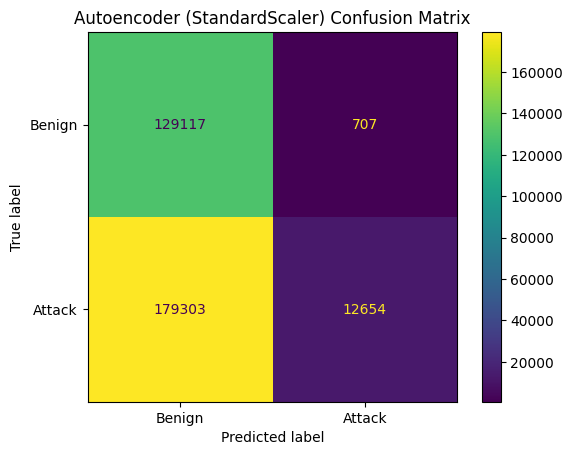

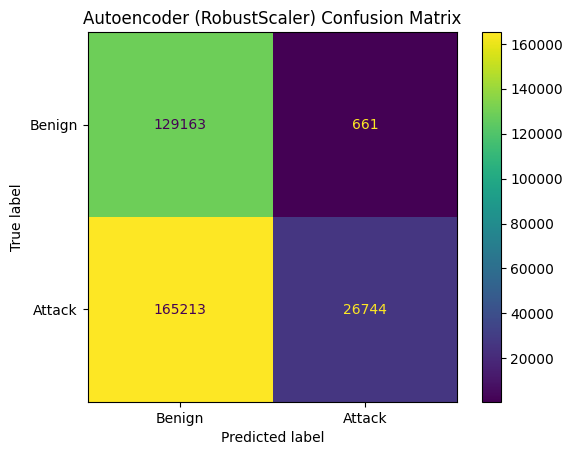

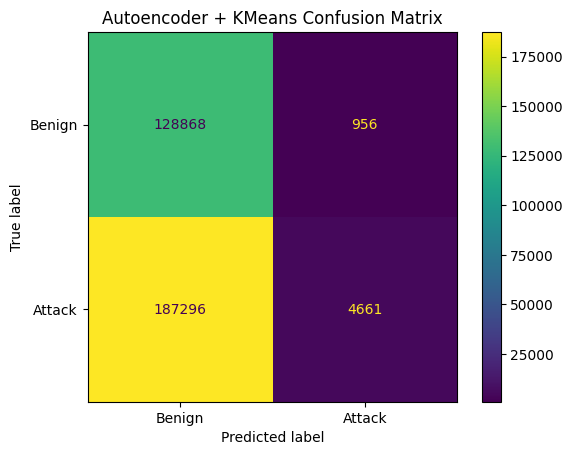

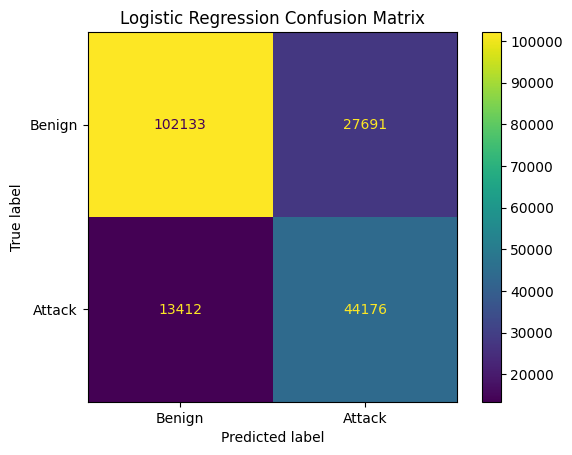

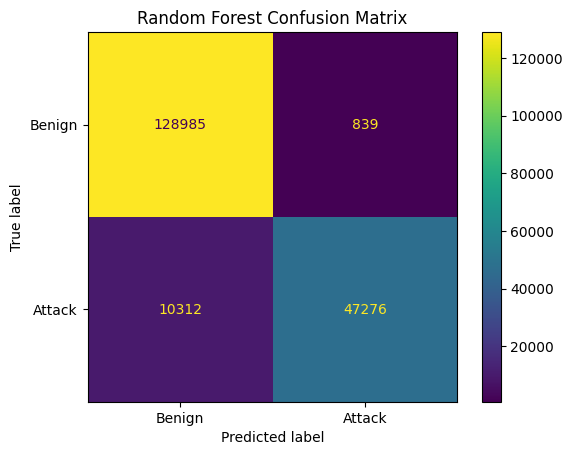

In [117]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

# --- Autoencoder (StandardScaler) ---
show_cm(
    y_test,
    ae_preds,
    "Autoencoder (StandardScaler) Confusion Matrix"
)

# --- Autoencoder (RobustScaler) ---
show_cm(
    y_test_robust,
    ae_robust_preds,
    "Autoencoder (RobustScaler) Confusion Matrix"
)

# --- AE + KMeans ---
show_cm(
    y_test,
    ae_km_preds,
    "Autoencoder + KMeans Confusion Matrix"
)

# --- Logistic Regression ---
show_cm(
    y_test_full,
    lr_preds,
    "Logistic Regression Confusion Matrix"
)

# --- Random Forest ---
show_cm(
    y_test_full,
    rf_15_preds,
    "Random Forest Confusion Matrix"
)

In [118]:
#Thresholding Logic to check if 0.5% FPR applied correctly
#Should be about 0.005
val_preds = (val_errors > threshold).astype(int)
val_fpr_check = val_preds.mean()
print("Validation-set FPR check (standard):", val_fpr_check)

val_preds_robust = (val_errors_robust > threshold_robust).astype(int)
val_fpr_check_robust = val_preds_robust.mean()
print("Validation-set FPR check (robust):", val_fpr_check_robust)

Validation-set FPR check (standard): 0.005000080542534513
Validation-set FPR check (robust): 0.005000080542534513


In [119]:
import time
import numpy as np

#latency evaluation
def measure_avg_latency(predict_fn, X, n_runs=5):
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = predict_fn(X)
        end = time.perf_counter()
        times.append(end - start)
    avg_s = np.mean(times)
    ms_per_sample = avg_s / len(X) * 1000
    return avg_s, ms_per_sample

#subset test
X_test_small = X_test[:10000]
X_test_full_small = X_test_full[:10000]

ae_total_s, ae_ms_per_sample = measure_avg_latency(
    lambda x: ae.predict(x, verbose=0),
    X_test_small
)

lr_total_s, lr_ms_per_sample = measure_avg_latency(
    lambda x: logreg.predict(x),
    X_test_full_small
)

rf_total_s, rf_ms_per_sample = measure_avg_latency(
    lambda x: rf_15_model.predict(x),
    X_test_full_small
)

#AE + K means
ae_km_total_s, ae_km_ms_per_sample = measure_avg_latency(
    lambda x: kmeans.transform(encoder.predict(x, verbose=0)),
    X_test_small
)

print("--- Latency Evaluation ---")
print(f"Autoencoder (StandardScaler) Total Time: {ae_total_s:.4f}s, MS per sample: {ae_ms_per_sample:.4f}ms")
print(f"Logistic Regression Total Time: {lr_total_s:.4f}s, MS per sample: {lr_ms_per_sample:.4f}ms")
print(f"Random Forest Total Time: {rf_total_s:.4f}s, MS per sample: {rf_ms_per_sample:.4f}ms")
print(f"Autoencoder + KMeans Total Time: {ae_km_total_s:.4f}s, MS per sample: {ae_km_ms_per_sample:.4f}ms")
ae_robust_total_s, ae_robust_ms_per_sample = measure_avg_latency(
    lambda x: ae_robust.predict(x, verbose=0),
    X_test_robust[:10000]
)

print(f"Autoencoder (RobustScaler) Total Time: {ae_robust_total_s:.4f}s, MS per sample: {ae_robust_ms_per_sample:.4f}ms")


#F1 scores
from sklearn.metrics import f1_score

ae_f1 = f1_score(y_test, ae_preds)
ae_robust_f1 = f1_score(y_test_robust, ae_robust_preds)
ae_km_f1 = f1_score(y_test, ae_km_preds)
lr_f1 = f1_score(y_test_full, lr_preds)
rf_f1 = f1_score(y_test_full, rf_15_preds)

print("--- F1 Scores ---")
print(f"Autoencoder (StandardScaler) F1 Score: {ae_f1}")
print(f"Autoencoder (RobustScaler) F1 Score: {ae_robust_f1}")
print(f"Autoencoder + KMeans F1 Score: {ae_km_f1}")
print(f"Logistic Regression F1 Score: {lr_f1}")
print(f"Random Forest F1 Score: {rf_f1}")


--- Latency Evaluation ---
Autoencoder (StandardScaler) Total Time: 0.5543s, MS per sample: 0.0554ms
Logistic Regression Total Time: 0.0009s, MS per sample: 0.0001ms
Random Forest Total Time: 0.0531s, MS per sample: 0.0053ms
Autoencoder + KMeans Total Time: 0.5235s, MS per sample: 0.0524ms
Autoencoder (RobustScaler) Total Time: 0.7561s, MS per sample: 0.0756ms
--- F1 Scores ---
Autoencoder (StandardScaler) F1 Score: 0.12326245141682658
Autoencoder (RobustScaler) F1 Score: 0.24383439246542246
Autoencoder + KMeans F1 Score: 0.04718232156052922
Logistic Regression F1 Score: 0.6824919856320729
Random Forest F1 Score: 0.8945063054028741


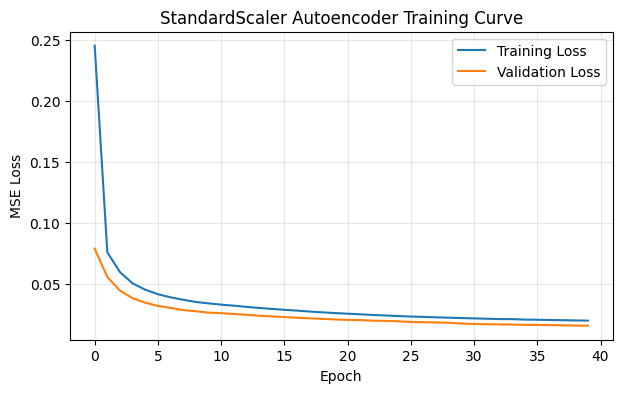

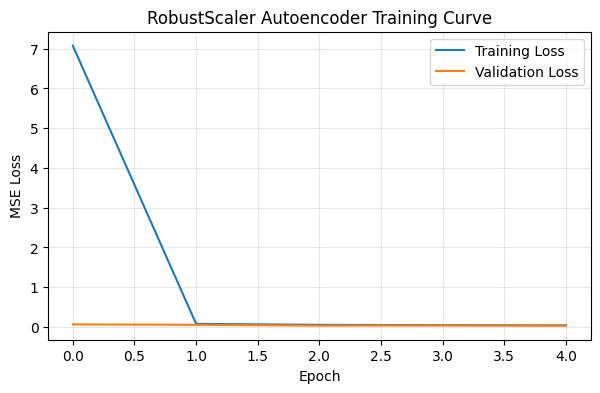

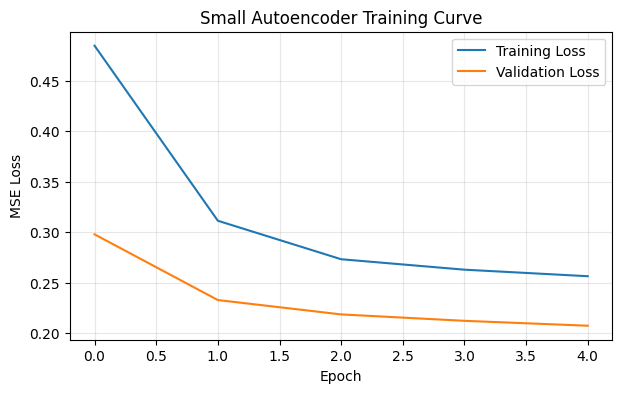

,Model,Size,Recall,FPR,F1,Latency (ms/sample),Lightweight?
0,AE (StandardScaler),3919 params,0.065921,0.005446,0.123262,0.055429,Yes
1,AE (RobustScaler),3919 params,0.139323,0.005092,0.243834,0.075606,Yes
2,AE + KMeans,3919 params + 64 centroid values,0.024281,0.007364,0.047182,0.052350,Yes
3,Logistic Regression,40 params,0.767104,0.213296,0.682492,0.000091,Yes
4,Random Forest,"15 trees, 912297 nodes",0.822845,0.006594,0.894506,0.005314,No
5,AE (Small),1451 params,0.022734,0.007271,0.044245,0.054432,Yes


In [120]:
#Training curve plots
import matplotlib.pyplot as plt

def plot_training_curve(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Standard AE
plot_training_curve(history, 'StandardScaler Autoencoder Training Curve')

# Robust AE
plot_training_curve(history_robust, 'RobustScaler Autoencoder Training Curve')

# Plot training curve for Small Autoencoder
plot_training_curve(history_small_ae, 'Small Autoencoder Training Curve')

#summary table
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Model": "AE (StandardScaler)",
        "Size": "3919 params",
        "Recall": ae_recall,
        "FPR": ae_fpr,
        "F1": ae_f1,
        "Latency (ms/sample)": ae_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "AE (RobustScaler)",
        "Size": "3919 params",
        "Recall": ae_robust_recall,
        "FPR": ae_robust_fpr,
        "F1": ae_robust_f1,
        "Latency (ms/sample)": ae_robust_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "AE + KMeans",
        "Size": "3919 params + 64 centroid values",
        "Recall": ae_k_recall,
        "FPR": ae_k_fpr,
        "F1": ae_km_f1,
        "Latency (ms/sample)": ae_km_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "Logistic Regression",
        "Size": "40 params",
        "Recall": lr_recall,
        "FPR": lr_fpr,
        "F1": lr_f1,
        "Latency (ms/sample)": lr_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "Random Forest",
        "Size": "15 trees, 912297 nodes",
        "Recall": rf_recall,
        "FPR": rf_fpr,
        "F1": rf_f1,
        "Latency (ms/sample)": rf_ms_per_sample,
        "Lightweight?": "No"
    },
    {
      "Model": "AE (Small)",
      "Size": f"{count_parameters(small_ae)} params",
      "Recall": small_ae_recall,
      "FPR": small_ae_fpr,
      "F1": small_ae_f1,
      "Latency (ms/sample)": small_ae_ms_per_sample,
      "Lightweight?": "Yes"
    }
])
display(summary_df)